<a href="https://colab.research.google.com/github/Deepika-J2106/customer-churn-prediction/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.info()
print(df.shape)
print(df.head())
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
print(df['TotalCharges'].isnull().sum())

11


In [5]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)

/tmp/ipykernel_26787/774761208.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)


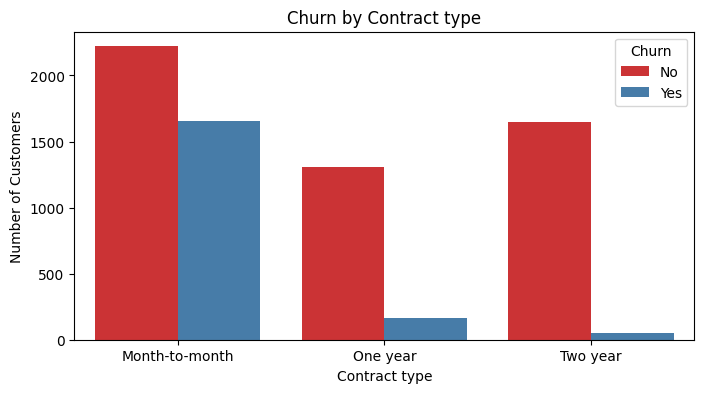

In [6]:
plt.figure(figsize = (8,4))
sns.countplot(data = df,x = 'Contract', hue = 'Churn', palette = 'Set1')
plt.title('Churn by Contract type')
plt.xlabel('Contract type')
plt.ylabel('Number of Customers')
plt.show()

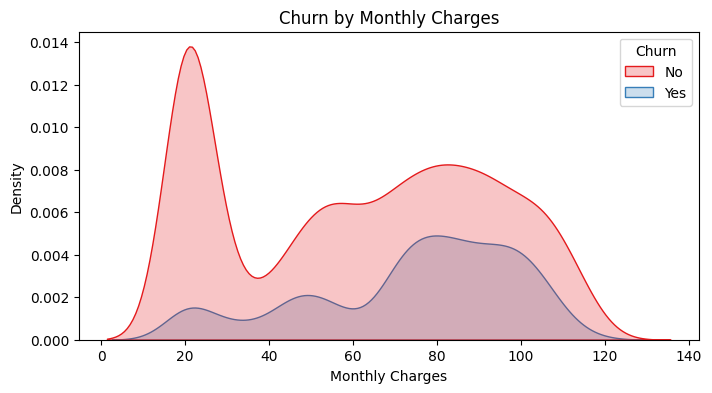

In [7]:
plt.figure(figsize = (8,4))
sns.kdeplot(data = df, x = 'MonthlyCharges', hue = 'Churn', fill = True, palette = 'Set1')
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.show()

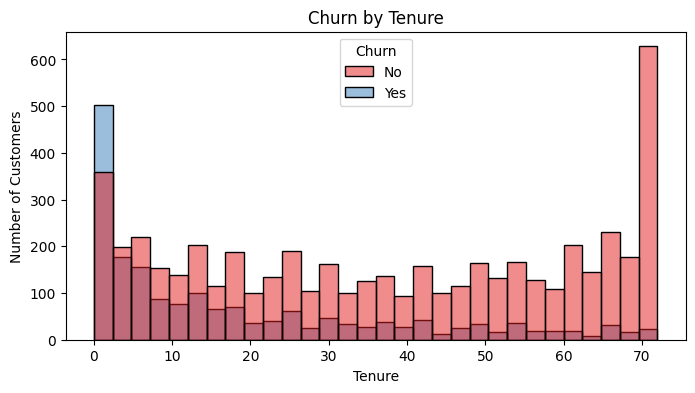

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(data = df, x = 'tenure',hue = 'Churn', bins = 30, palette = 'Set1')
plt.title('Churn by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Number of Customers')
plt.show()

In [9]:
df = df.drop('customerID',axis = 1)
X = df.drop('Churn',axis = 1)
Y = df['Churn'].map({'Yes': 1, 'No' : 0})

In [10]:
X = pd.get_dummies(X,drop_first=True)

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Fresh load — avoids stale variable issues
df2 = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2['TotalCharges'].fillna(df2['TotalCharges'].median(), inplace=True)
df2 = df2.drop('customerID', axis=1)

X = df2.drop('Churn', axis=1)
y = df2['Churn'].map({'Yes': 1, 'No': 0})
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Training shape:", X_train_res.shape)
print("Test shape:", X_test.shape)
print("Class balance:", y_train_res.value_counts().to_dict())

Training shape: (8278, 30)
Test shape: (1409, 30)
Class balance: {0: 4139, 1: 4139}


/tmp/ipykernel_26787/1459795138.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['TotalCharges'].fillna(df2['TotalCharges'].median(), inplace=True)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc
    print(f"{name}: AUC-ROC = {auc:.4f}")

print("\n--- Model Comparison ---")
for name, auc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {auc:.4f}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} — AUC-ROC: {results[best_model_name]:.4f}")

preds = best_model.predict(X_test)
print(f"\nClassification Report — {best_model_name}")
print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: AUC-ROC = 0.8115
Random Forest: AUC-ROC = 0.8210


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: AUC-ROC = 0.8144

--- Model Comparison ---
Random Forest: 0.8210
XGBoost: 0.8144
Logistic Regression: 0.8115

Best model: Random Forest — AUC-ROC: 0.8210

Classification Report — Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [26]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
param_grid = {
    'n_estimators' : [100,200,300,400,500],
    'max_depth' : [5,10,15,20,25,30,None],
    'min_samples_split' : [2, 5, 10, 15, 20],
    'min_samples_leaf' : [1,2,4,6,8],
    'max_features' : ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state = 42)
rs = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_grid,
    n_iter = 50,
    cv = 5,
    scoring = 'roc_auc',
    random_state = 42,
    n_jobs=-1,
    verbose = 1
)
print("Tuning Random Forest")
rs.fit(X_train_res,y_train_res)
for param, value in rs.best_params_.items():
  print(f" {param}: {value}")
print(f"\nBest cross-validated AUC-ROC : {rs.best_score_:.4f}")

Tuning Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits
 n_estimators: 100
 min_samples_split: 5
 min_samples_leaf: 1
 max_features: log2
 max_depth: None

Best cross-validated AUC-ROC : 0.9286


In [28]:
best_rf = rs.best_estimator_
probs_tuned = best_rf.predict_proba(X_test)[:,1]
preds_tuned = best_rf.predict(X_test)
auc_tuned = roc_auc_score(y_test,probs_tuned)
print(f"\n Tuned Random Forest AUC-ROC : {auc_tuned:.4f}")
print(f"Previous AUC-ROC:            0.8210")
print(f"Improvement:                 +{(auc_tuned - 0.8210):.4f}")
print("\nClassification Report — Tuned Random Forest")
print(classification_report(y_test, preds_tuned, target_names=['No Churn', 'Churn']))


 Tuned Random Forest AUC-ROC : 0.8243
Previous AUC-ROC:            0.8210
Improvement:                 +0.0033

Classification Report — Tuned Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

